# Google Colab Lab Assignment -Pretrained Modle

**Course Name:** Deep Learning

**Lab Title:** Transfer Learning with VGG16 and ResNet50 for Pneumonia Detection from Chest X-ray Images

**Student Name:** Pratik Pravin Bhosale

**Student ID:** 202301100005

**Date of Submission:** 24/02/2026

**Group Members**: Yash Dalvi, Arnav Bapat , Pritesh Purkar

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path (Kaggle auto path)
DATASET_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = val_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

In [9]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze base layers

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

2026-02-24 17:43:25.385373: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.6980 - loss: 0.6338 - val_accuracy: 0.5000 - val_loss: 0.7745
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.7425 - loss: 0.5661 - val_accuracy: 0.5000 - val_loss: 0.7907
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.7503 - loss: 0.5411 - val_accuracy: 0.5000 - val_loss: 0.8007
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.7524 - loss: 0.5245 - val_accuracy: 0.5000 - val_loss: 0.7297
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.7494 - loss: 0.5209 - val_accuracy: 0.5000 - val_loss: 0.8113


In [10]:
base_model.trainable = True

for layer in base_model.layers[:140]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 632s 4s/step - accuracy: 0.8170 - loss: 0.3631 - val_accuracy: 0.5000 - val_loss: 0.9273
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 617s 4s/step - accuracy: 0.9443 - loss: 0.1469 - val_accuracy: 0.5000 - val_loss: 1.8700
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 613s 4s/step - accuracy: 0.9434 - loss: 0.1454 - val_accuracy: 0.5000 - val_loss: 3.0311


**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

predictions = model.predict(test_data)
pred_classes = (predictions > 0.5).astype(int)

print(classification_report(test_data.classes, pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.3143 - loss: 3.9578
Test Accuracy: 0.6330128312110901
20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step
              precision    recall  f1-score   support

           0       1.00      0.02      0.04       234
           1       0.63      1.00      0.77       390

    accuracy                           0.63       624
   macro avg       0.82      0.51      0.41       624
weighted avg       0.77      0.63      0.50       624



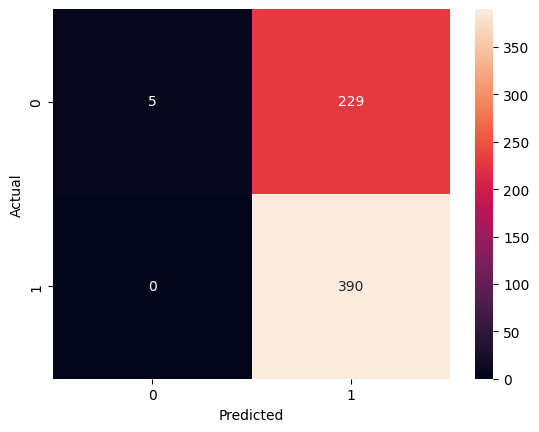

In [12]:
cm = confusion_matrix(test_data.classes, pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

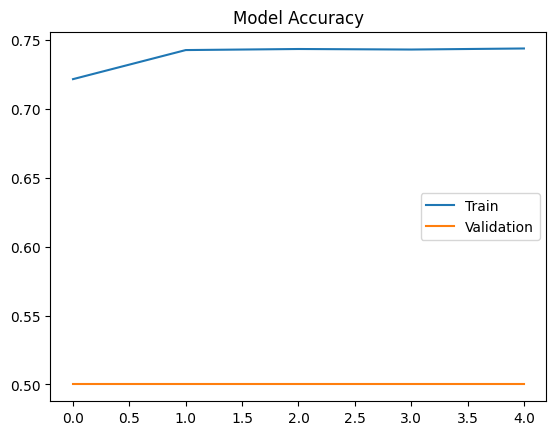

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

**Declaration**

I, Pratik Bhosale, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: Pratik Pravin Bhosale